In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('item_matrix.csv')
df.head()

,target_name,source_name,distance
0,the pocket mentor for video game testing,visual research a concise introduction to thin...,0.310783
1,machine learning in accounting practical guide...,visual research a concise introduction to thin...,0.274997
2,computer aided and machine learning driven dru...,visual research a concise introduction to thin...,0.275273
3,surface environment and human interactions ref...,visual research a concise introduction to thin...,0.228757
4,biotic resources circular bio economy perspective,visual research a concise introduction to thin...,0.209669


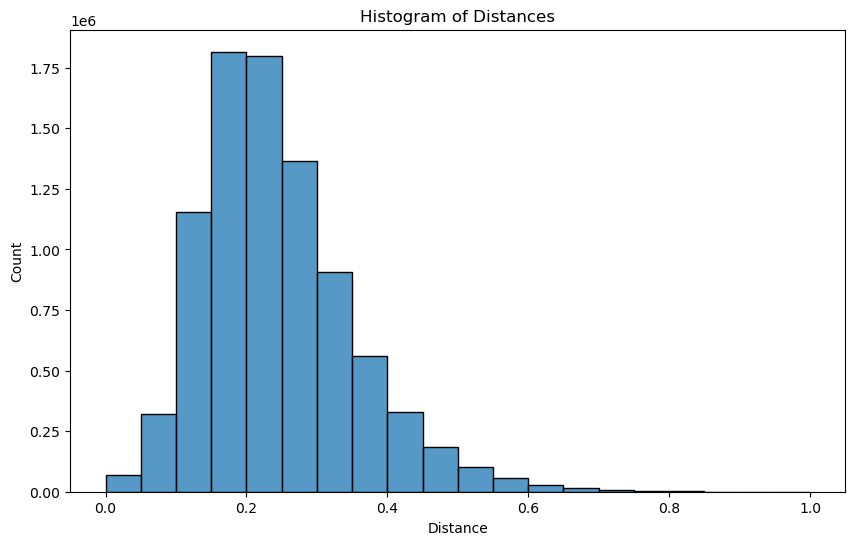

In [2]:
# PLot histogram of distances
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='distance', bins=20)
plt.xlabel('Distance')
plt.ylabel('Count')
plt.title('Histogram of Distances')
plt.show()

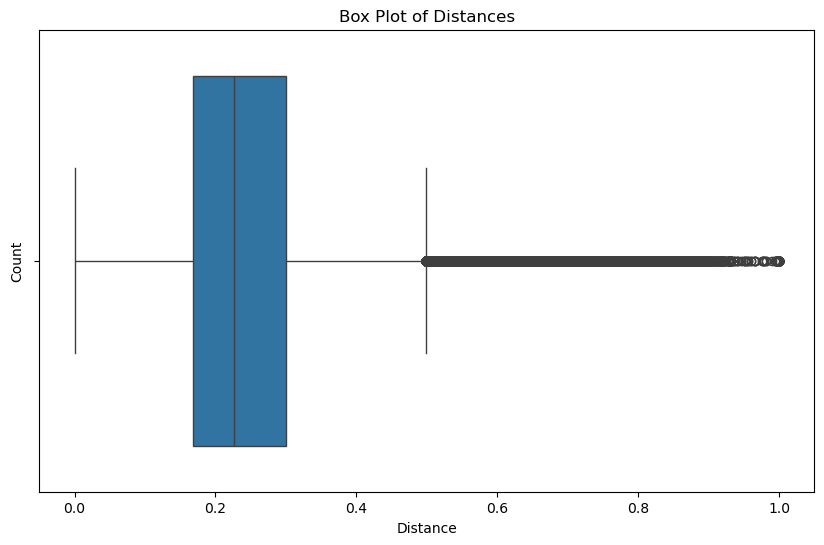

In [3]:
# Whisker and box plot of distances
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='distance')
plt.xlabel('Distance')
plt.ylabel('Count')
plt.title('Box Plot of Distances')
plt.show()

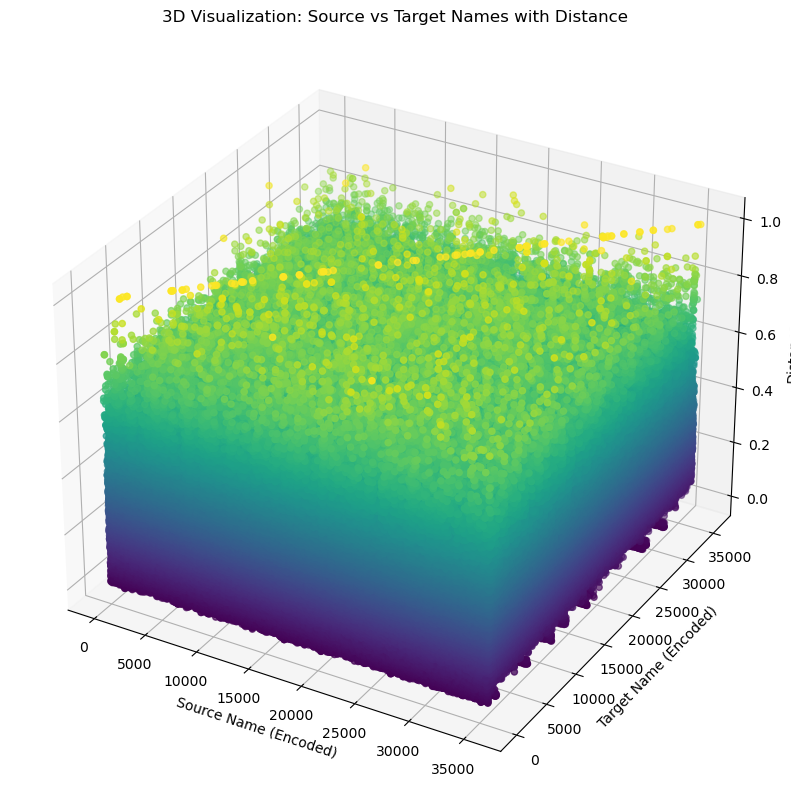

In [4]:
# Encode file names
file_name = set(df['source_name'].unique().tolist())
file_name2 = set(df['target_name'].unique().tolist())
file_name = file_name.union(file_name2)
file_name = list(file_name)
file_name.sort()
file_name = {file_name[i]: i*10 for i in range(len(file_name))}

# Map the encoded names
df['source_encoded'] = df['source_name'].map(file_name)
df['target_encoded'] = df['target_name'].map(file_name)

# Plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['source_encoded'], df['target_encoded'], df['distance'], 
           c=df['distance'], cmap='viridis', marker='o')

ax.set_xlabel('Source Name (Encoded)')
ax.set_ylabel('Target Name (Encoded)')
ax.set_zlabel('Distance')

ax.set_title('3D Visualization: Source vs Target Names with Distance')

plt.show()

In [5]:
def compute_top_means(group):
    distances = group['distance'].sort_values(ascending=False).reset_index(drop=True)
    n = len(distances)
    
    return pd.Series({
        'mean_100': distances.mean(),
        'mean_75_top': distances.iloc[:int(n*0.75)].mean(),
        'mean_50_top': distances.iloc[:int(n*0.50)].mean(),
        'mean_25_top': distances.iloc[:int(n*0.25)].mean(),
        'mean_10_top': distances.iloc[:int(n*0.10)].mean(),
        'mean_5_top':  distances.iloc[:int(n*0.05)].mean()
    })

# Apply the function to each group
file_distance = df.groupby('source_name').apply(compute_top_means).reset_index()

# Add encoded_name column
file_distance['encoded_name'] = file_distance['source_name'].map(file_name)

# Optional: reorder columns
file_distance = file_distance[['source_name', 'encoded_name', 
                               'mean_100', 'mean_75_top', 
                               'mean_50_top', 'mean_25_top', 
                               'mean_10_top', 'mean_5_top']]
# Export the DataFrame to a CSV file
file_distance.to_csv('file_distance.csv', index=False)

file_distance.head(n=25)


,source_name,encoded_name,mean_100,mean_75_top,mean_50_top,mean_25_top,mean_10_top,mean_5_top
0,100 site analysis essentials an architect guide,0,0.184145,0.209009,0.231965,0.261843,0.297193,0.323788
1,15 math concepts every data scientist should k...,10,0.279652,0.318189,0.361507,0.425891,0.495572,0.540782
2,150+ C pattern programs top C exercises to fee...,20,0.075485,0.095924,0.126029,0.175414,0.236275,0.279416
3,150+ JavaScript pattern programs top JS exerci...,30,0.069264,0.088027,0.115377,0.164405,0.228776,0.275793
4,150+ Python pattern programs top Python exerci...,40,0.071891,0.090894,0.119466,0.171125,0.242343,0.294995
5,200 problems on languages automata and computa...,50,0.207287,0.238603,0.277214,0.344610,0.426341,0.476830
6,2D materials based sensors technology and appl...,60,0.229184,0.261279,0.299107,0.359012,0.433762,0.488007
7,2D metals fundamentals emerging applications a...,70,0.260236,0.296127,0.337697,0.406938,0.501135,0.567124
8,3D and 4D printing of bioadhesive pharmaceutic...,80,0.246366,0.280668,0.321390,0.387607,0.469651,0.521522
9,3D computer vision foundations and advanced me...,90,0.283211,0.317440,0.353900,0.405018,0.471544,0.523725


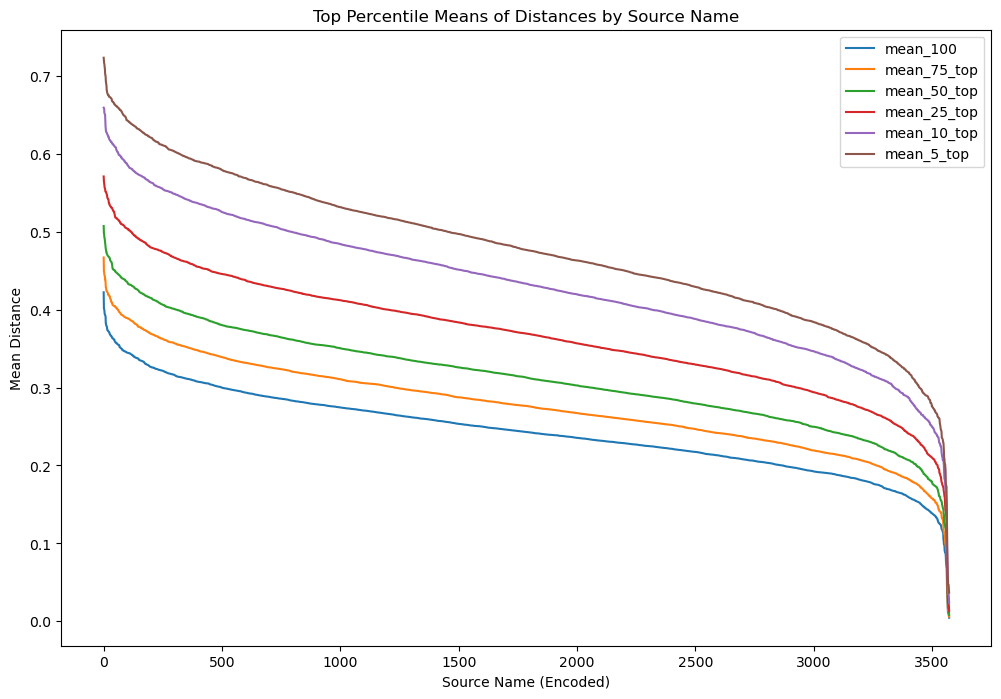

In [6]:
top_percentile_means = file_distance.columns[2:].tolist()
top_n = 25

plt.figure(figsize=(12, 8))
plt.title('Top Percentile Means of Distances by Source Name')
for col in top_percentile_means:
    sorted_means = file_distance[col].sort_values(ascending=False).reset_index(drop=True)
    plt.plot(sorted_means.values, label=col)

plt.xlabel('Source Name (Encoded)')
plt.ylabel('Mean Distance')
plt.legend()
plt.show()

In [7]:
top_percentile_means = file_distance.columns[2:].tolist()
top_n = 25

for col in top_percentile_means:
    sorted_means = file_distance[col].sort_values(ascending=False).reset_index(drop=True)

    # Print top n values for each mean
    sorted_means = file_distance[col].sort_values(ascending=False)

    # Get the top n indexes (these correspond to the original rows)
    top_indexes = sorted_means.index[:top_n]

    # Create a DataFrame with file names and mean values
    top_files = file_distance.loc[top_indexes, ['source_name']].copy()
    top_files['mean'] = sorted_means.iloc[:top_n].values

    print(f"\nTop {top_n} values for {col}:")
    for index, row in top_files.iterrows():
        print(f"- {row['mean']}: {row['source_name']}")



Top 25 values for mean_100:
- 0.42221199666107273: system innovation for an artificial intelligence era applied system innovation X
- 0.40169736795098876: mechanical engineer handbook design instrumentation and control
- 0.4006035343240168: mechanical engineer handbook manufacturing and management
- 0.3991919318308193: handbook of intelligent computing and optimization for sustainable development
- 0.3950472795954333: the mechatronics handbook the instrumentations systems and automation society
- 0.3937034329825835: automatic control mechatronics and industrial engineering
- 0.39340124533629184: artificial intelligent a modern approach
- 0.39217104220031335: hybrid computational intelligent systems modeling simulation and optimization
- 0.39107071506053914: automation and computation
- 0.3819045518926339: industrial engineering and applications Europe
- 0.3815966635225923: system analysis in engineering and control
- 0.3798591528914692: handbook of engineering statistics
- 0.378506883

In [8]:
top_percentile_means = file_distance.columns[2:].tolist()
top_n = 25

for col in top_percentile_means:
    sorted_means = file_distance[col].sort_values(ascending=False).reset_index(drop=True)

    # Print top n values for each mean
    sorted_means = file_distance[col].sort_values(ascending=False)

    # Get the top n indexes (these correspond to the original rows)
    bottom_indexes = sorted_means.index[-top_n:]

    # Create a DataFrame with file names and mean values for bottom n
    bottom_files = file_distance.loc[bottom_indexes, ['source_name']].copy()
    bottom_files['mean'] = sorted_means.iloc[-top_n:].values

    print(f"\nBottom {top_n} values for {col}:")
    for index, row in bottom_files.iterrows():
        print(f"- {row['mean']}: {row['source_name']}")



Bottom 25 values for mean_100:
- 0.1047411721556399: avian architecture how birds design engineer and build
- 0.10363581019973277: game jam history technology and organization
- 0.09900461838612903: embedded systems circuits and programming
- 0.09828169857042203: KAWAII cafe bubble tea classic fun and refreshing boba drinks to make at home
- 0.09758728951307233: mathematics manual for water and wastewater treatment plant operators wastewater treatment operations math concepts and calculation
- 0.09085859710217802: dot and dashes Duane learns the magic of Morse code
- 0.08939853376121838: R calculus V description logics
- 0.08826269471573525: digital signal and image processing using MATLAB
- 0.08788850922054361: Litt drug eruption and reaction manual 30th edition
- 0.08752943704939949: Java easy for beginners coders 2 book in 1 from zero to creating your Java projects and much more
- 0.08287300325074526: cookie lab cookbook mastering perfect cookies with kitchen chemistry
- 0.07548529